### #IMPORTING LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

### #LOADING DATABASE

In [ ]:
df = pd.read_csv("Data/heart.csv")

print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

Shape: (918, 12)

First 5 rows:
   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up             0  
1              N      1.0     Flat             1  
2              N      0.0       Up             0  
3              Y      1.5     Flat             1  
4              N      0.0       Up             0  


### #BASIC INFO

In [3]:
print("\nInfo:")
print(df.info())

print("\nDescription:")
print(df.describe(include="all"))


Info:
<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB
None

Description:
               Age  Sex ChestPainType   RestingBP  Cholesterol   FastingBS  \
count   918.000000  918           918  918.000000   918.000000  918.000000   
unique         NaN    2            

### ---HANDLING MISSING AND INVALID VALUES---

In [4]:
print("\nMissing values:")
print(df.isnull().sum())

# Check zero values (invalid for some columns)
print("\nZero values count:")
print((df == 0).sum())


Missing values:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

Zero values count:
Age                 0
Sex                 0
ChestPainType       0
RestingBP           1
Cholesterol       172
FastingBS         704
RestingECG          0
MaxHR               0
ExerciseAngina      0
Oldpeak           368
ST_Slope            0
HeartDisease      410
dtype: int64


In [5]:
# Replace invalid zeros with NaN
df['RestingBP'] = df['RestingBP'].replace(0, np.nan)
df['Cholesterol'] = df['Cholesterol'].replace(0, np.nan)

# Fill missing values
df['Cholesterol'] = df['Cholesterol'].fillna(df['Cholesterol'].mean())
df['RestingBP'] = df['RestingBP'].fillna(df['RestingBP'].mean())

In [6]:
print(df['Cholesterol'].isnull().sum())

0


### Insights
- Although no explicit missing values were found , certain features contained zero values that are medically unrealistic aand were treated as missing data

In [7]:
cat_cols = df.select_dtypes(include='object').columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

print("\nCategorical Columns:", cat_cols)
print("Numerical Columns:", num_cols)


Categorical Columns: Index(['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'], dtype='str')
Numerical Columns: Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'HeartDisease'],
      dtype='str')


C:\Users\Vanshika\AppData\Local\Temp\ipykernel_16408\3273664475.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns


### ---TARGET VALUE ANALYSIS---

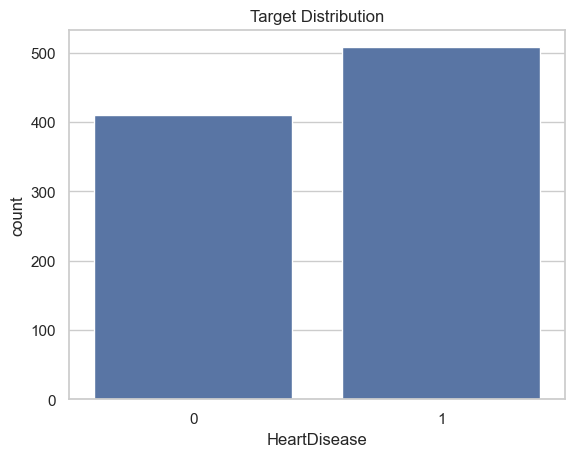


Target Distribution:
HeartDisease
1    0.553377
0    0.446623
Name: proportion, dtype: float64


In [8]:
sns.countplot(x='HeartDisease', data=df)
plt.title("Target Distribution")
plt.show()

print("\nTarget Distribution:")
print(df['HeartDisease'].value_counts(normalize=True))

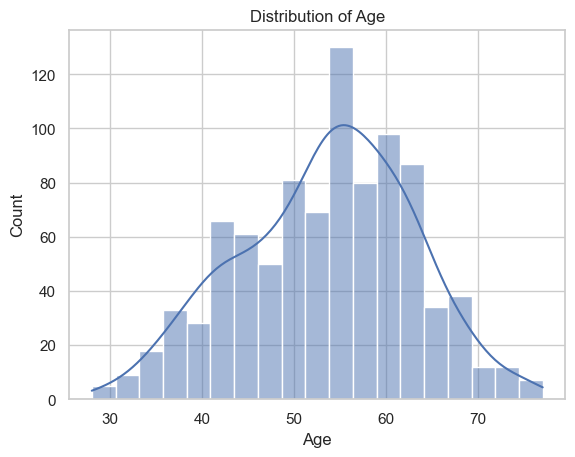

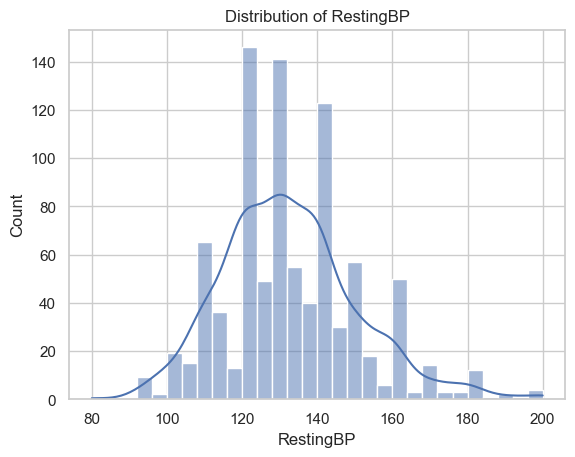

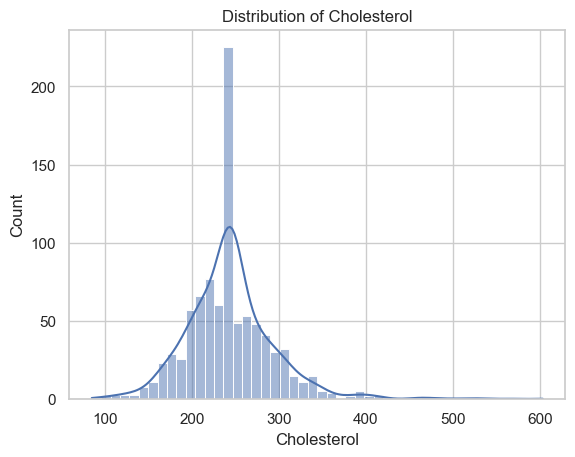

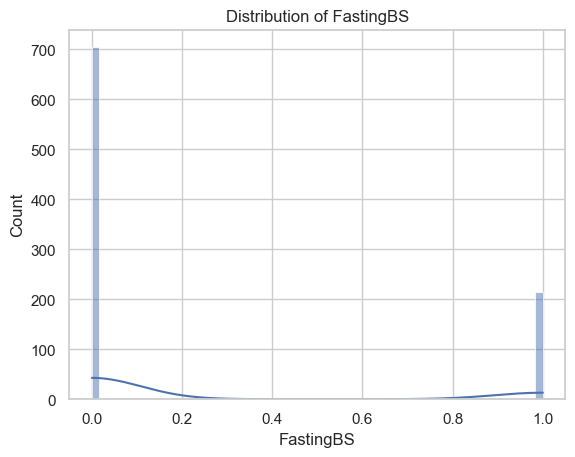

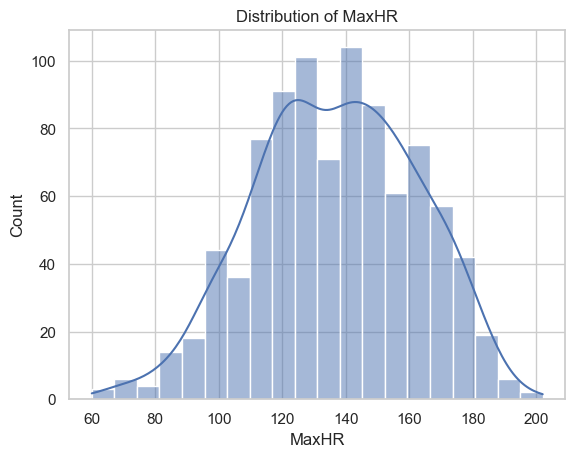

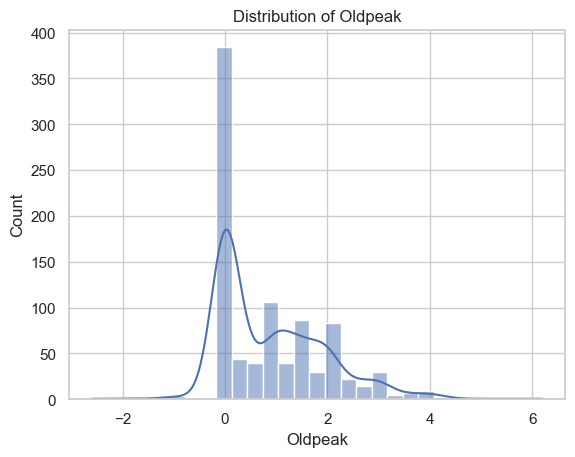

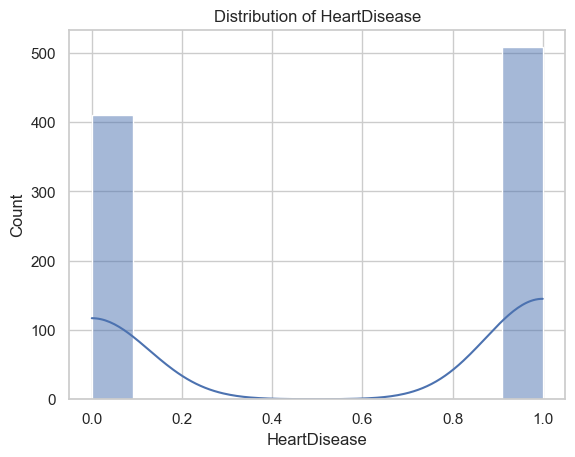

In [9]:
#Univariate Analysis
#checking for the distribution of variable
for col in num_cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

## Univariate Analysis
- Majority of patients fall in the 40-60 age range, indicating higher concenntration in middle aged group
- Cholesterol shows high variability, suggesting presence of outliers
- Dataset contains moore male than female patients, indicating slight gender imbalance
- OldPeak is right-skewed, with most values near zero and few extreme values

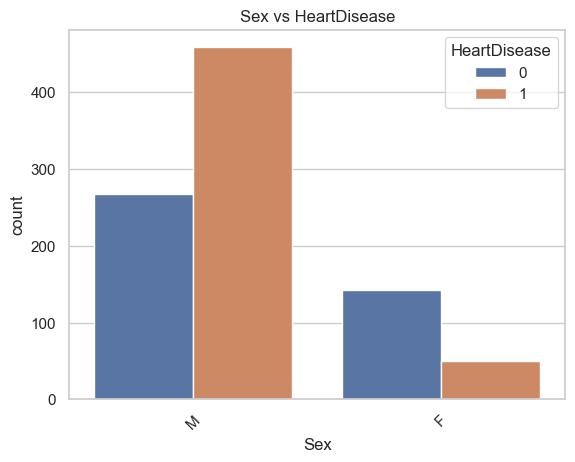

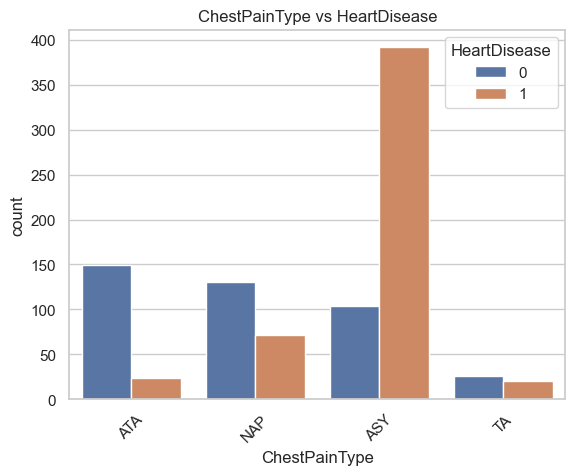

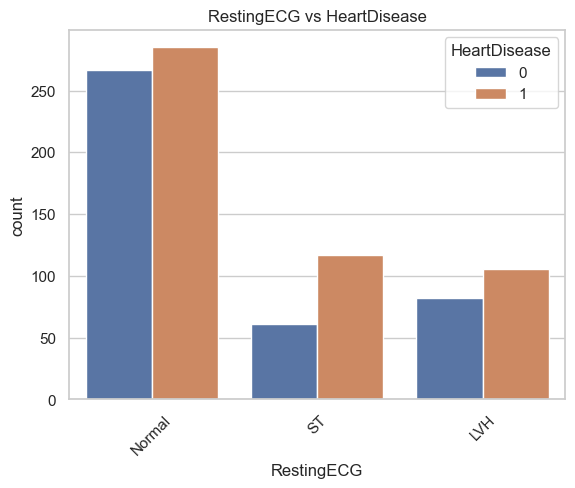

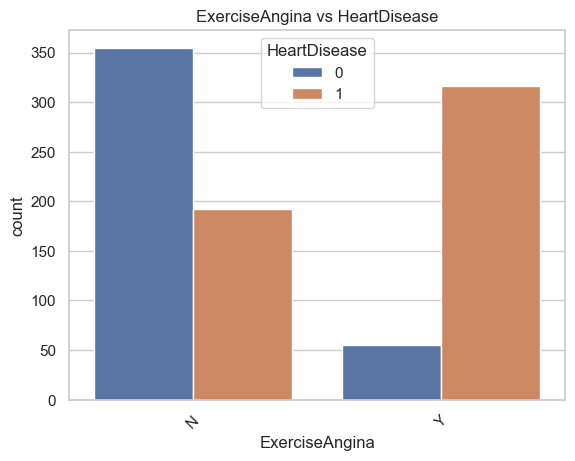

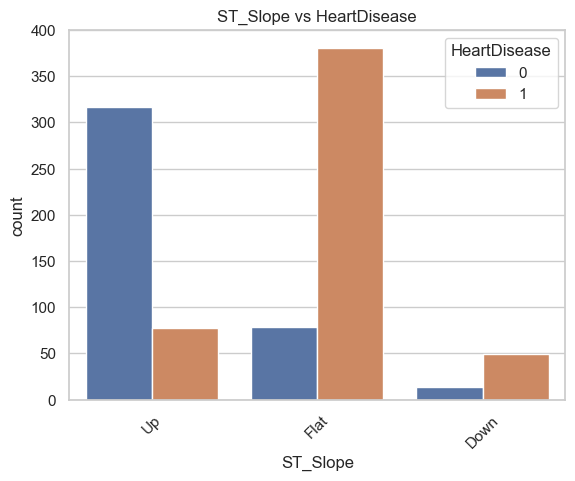

In [10]:
#Bivariate Analysis
#checking for the relationship between target variable and other variables

for col in cat_cols:
    plt.figure()
    sns.countplot(x=col, hue='HeartDisease', data=df)
    plt.title(f"{col} vs HeartDisease")
    plt.xticks(rotation=45)
    plt.show()

## Insights
- Male patients exibhits a higher prevalence of heart disease compared to females, indicating gender as a significant risk factor.
- Patients with asymptomatic chest pain (ASY) show a significantly higher likelihood of disease.
- The presence of excercise-induced anigma is strongly associated with heart disease.
- Older individials are more likely to suffer from herat disease.
- Patient with heat disease are likely to have higher OldPeak values, showing a strong posituve relation between ST depression and heart disease.
- Maximum Heart Rate (MaxHR) tends to be lower in patients with heart disease.
- Certain ST_slope categories (especially flats) are more associated with heart disease, highlighting its diagnostic importance.
- Features like Resting ECG show weaker or less consistent relationships, suggesting they may be less influential predictors.

##### These observations indicates that features such as age, chest pain type, exercise induces anigma, oldpeak and Max heart rate are significant pridictors of heart disease and should be prioritized during model training.

### ---CATEGORICAL ANALYSIS---

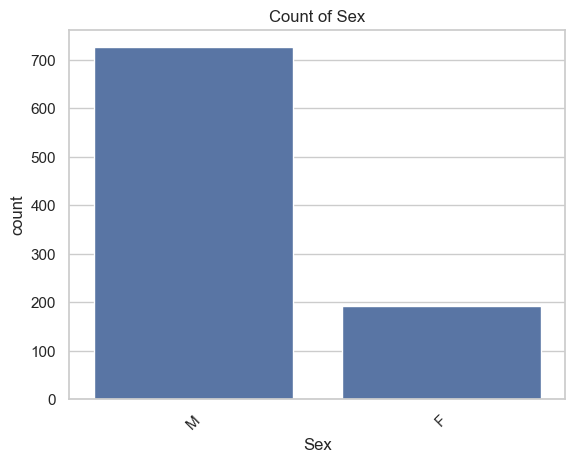

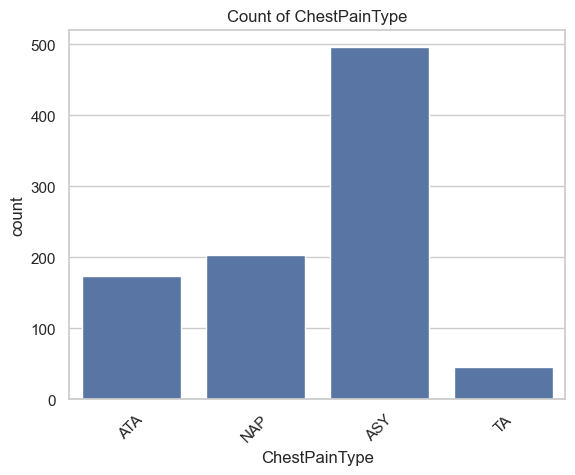

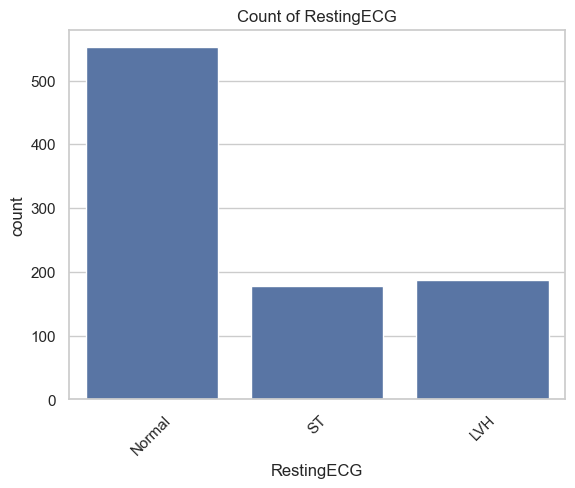

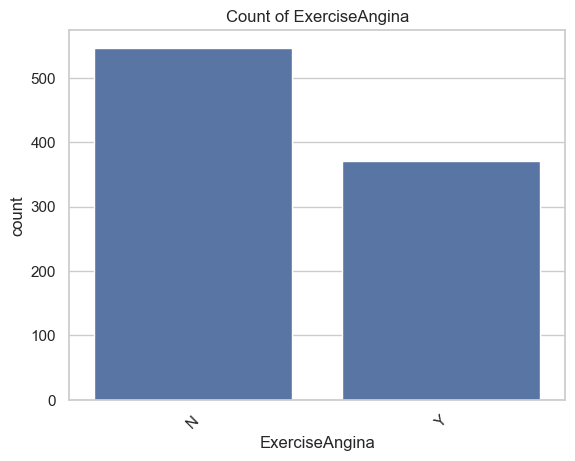

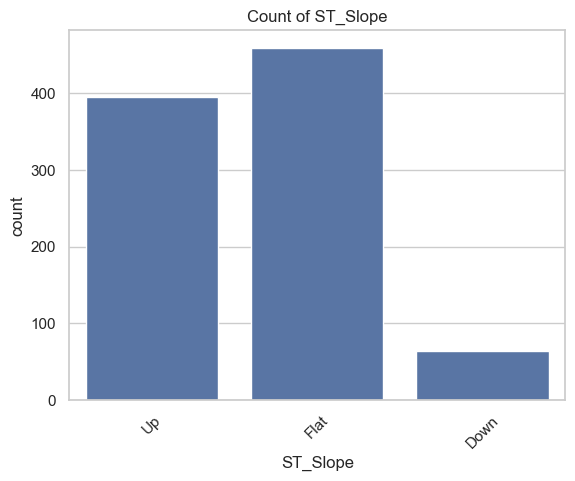

In [11]:
for col in cat_cols:
    plt.figure()
    sns.countplot(x=col, data=df)
    plt.title(f"Count of {col}")
    plt.xticks(rotation=45)
    plt.show()

### ---OUTLIER DETECTION---

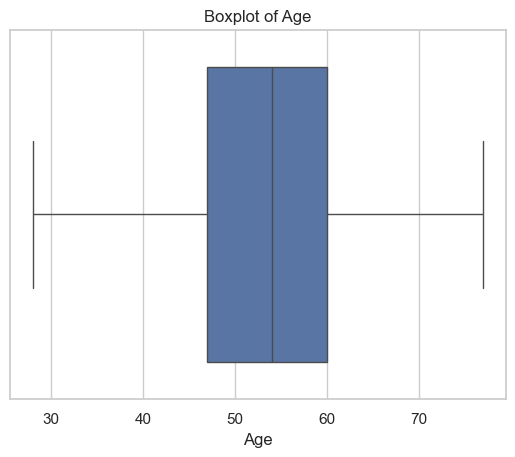

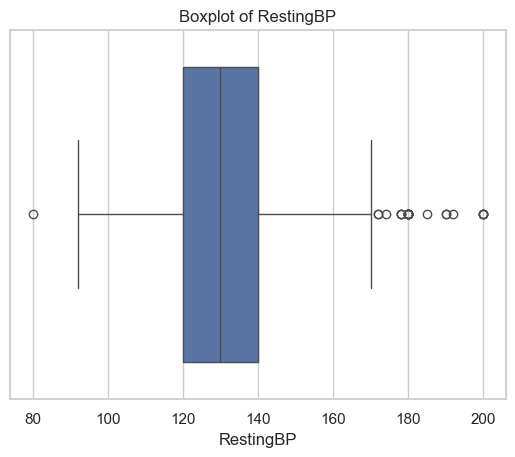

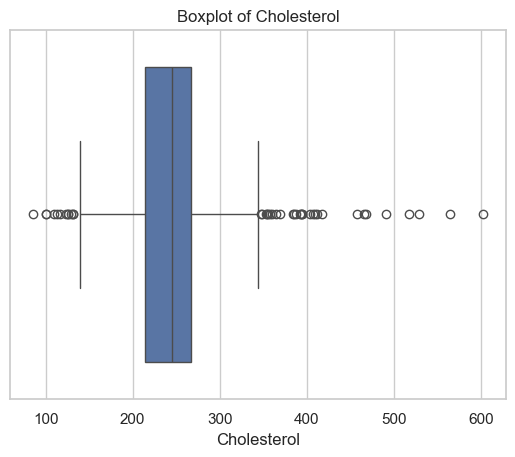

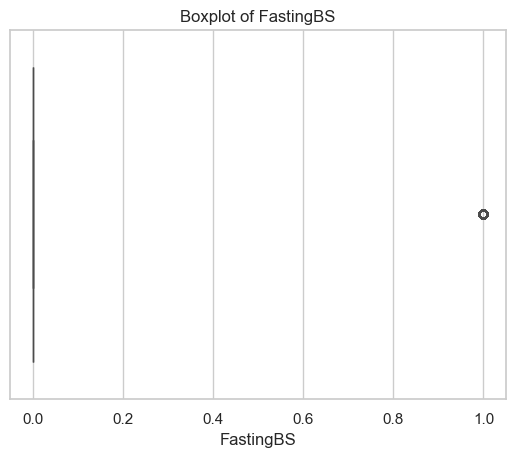

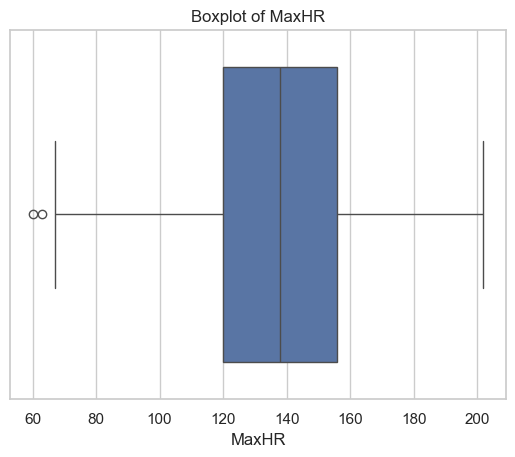

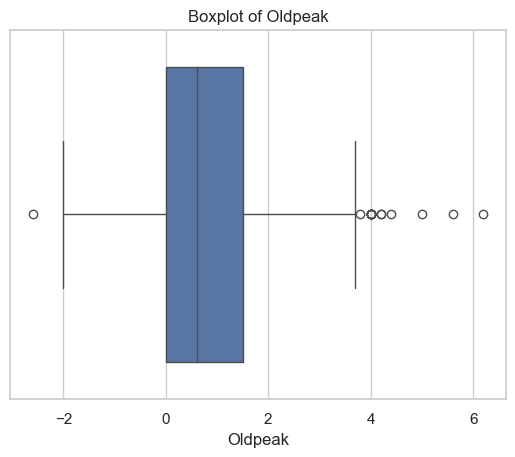

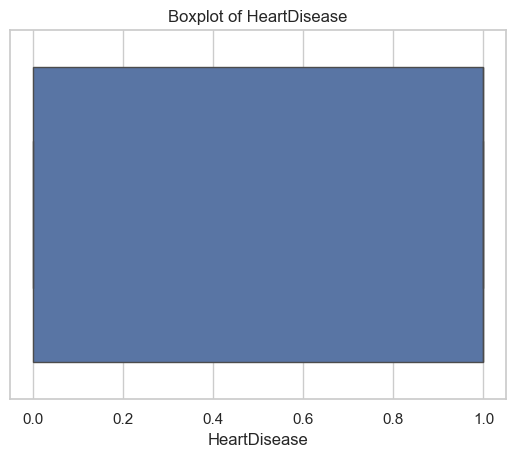

In [12]:
for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

- We are not removing outliers instead we are setting a limit for them because human bodies can have some extra high parameters.
- “Outliers were analyzed using boxplots. Since the dataset is medical, extreme values may represent real conditions, so capping was preferred over removal.”

In [13]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = np.clip(df[col], lower, upper)

### ---ENCODING OUR DATA---

In [14]:
df_encoded = pd.get_dummies(df, drop_first=True)

print("\nAfter Encoding Shape:", df_encoded.shape)


After Encoding Shape: (918, 16)


### Converting Categorical Variables to Numeric
- Sex : M=0, F=1
- ChestPainType : ATA=0, NAP=1, ASY=2, TA=3
- RestingECG : Normal=0,ST=1,LVH=2
- ExerciseAnigna : N=0, Y=1
- ST_Slope : Up=0, Flat=1, Down=2

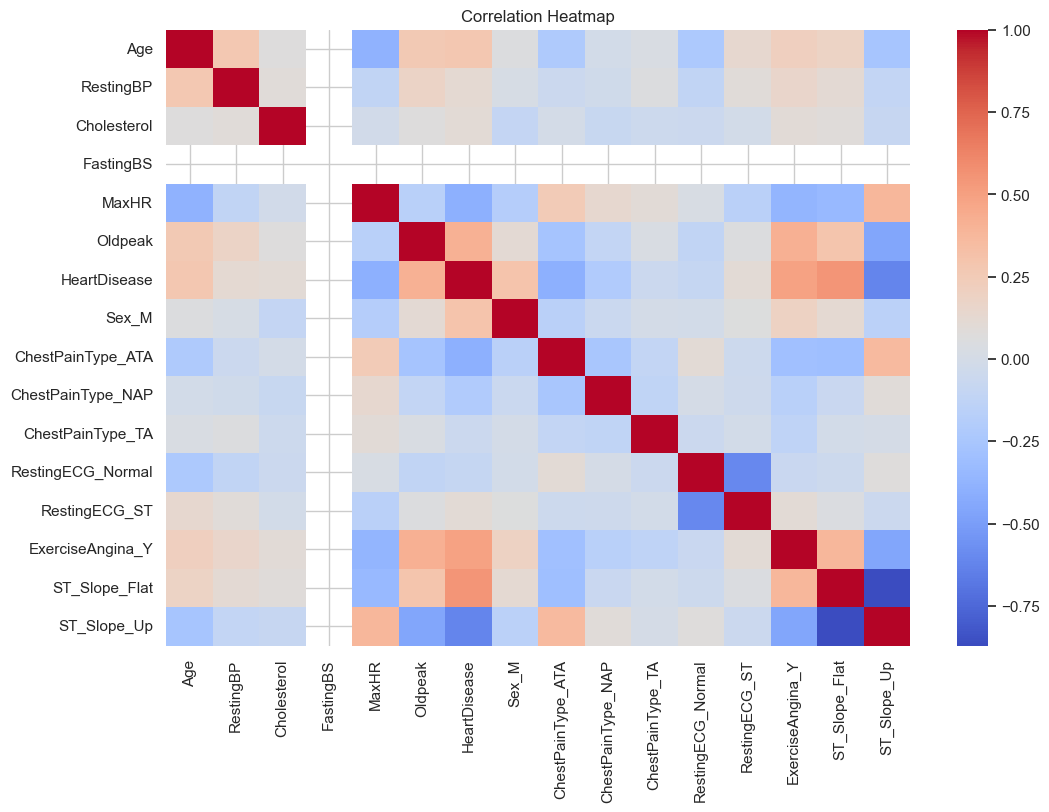


Correlation with Target:
HeartDisease         1.000000
ST_Slope_Flat        0.554134
ExerciseAngina_Y     0.494282
Oldpeak              0.410211
Sex_M                0.305445
Age                  0.282039
RestingBP            0.116032
Cholesterol          0.104567
RestingECG_ST        0.102527
ChestPainType_TA    -0.054790
RestingECG_Normal   -0.091580
ChestPainType_NAP   -0.212964
MaxHR               -0.400519
ChestPainType_ATA   -0.401924
ST_Slope_Up         -0.622164
FastingBS                 NaN
Name: HeartDisease, dtype: float64


In [15]:
# Correlation Analysis
plt.figure(figsize=(12,8))
sns.heatmap(df_encoded.corr(), annot=False, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Correlation with target
print("\nCorrelation with Target:")
print(df_encoded.corr()['HeartDisease'].sort_values(ascending=False))

### ---REMOVE HIGHLY CORRELATED FEATURES---

In [16]:
corr_matrix = df_encoded.corr().abs()

upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop = [col for col in upper_triangle.columns if any(upper_triangle[col] > 0.9)]

print("\nHighly correlated features to drop:", to_drop)

df_encoded.drop(columns=to_drop, inplace=True)


Highly correlated features to drop: []


In [17]:
df_encoded = df_encoded.astype(int)

In [18]:
df_encoded.dtypes

Age                  int64
RestingBP            int64
Cholesterol          int64
FastingBS            int64
MaxHR                int64
Oldpeak              int64
HeartDisease         int64
Sex_M                int64
ChestPainType_ATA    int64
ChestPainType_NAP    int64
ChestPainType_TA     int64
RestingECG_Normal    int64
RestingECG_ST        int64
ExerciseAngina_Y     int64
ST_Slope_Flat        int64
ST_Slope_Up          int64
dtype: object

### ---SAVING THE FINAL DATASET---

In [19]:
print("\nFinal dataset shape:", df_encoded.shape)

df_encoded.to_csv("Data/heart_cleaned.csv", index=False)


Final dataset shape: (918, 16)
